# Introduction

Metallic nanoparticles, particularly those made of gold (Au), have the unique ability to strongly interact with light at specific wavelengths through a phenomenon known as Localized Surface Plasmon Resonance (LSPR). When illuminated at their resonance frequency, these nanoparticles become highly efficient at absorbing light and converting it into heat on the nanoscale. This localized heat generation is the foundation of Plasmonic Photothermal Therapy (PPTT), a technique for applications like selective oncological treatment. By delivering nanoparticles to a target volume (e.g., a tumor) and illuminating them with light (often in the near-infrared, where biological tissue is most transparent), it's possible to induce hyperthermia with high precision, minimizing damage to surrounding healthy tissue. Computational modeling tools, such as Tidy3D, offers a powerful tool for predicting the temperature increase for different nanoparticle shapes, sizes, and arrangements, allowing scientists to rapidly simulate and predict thermal outcomes.

This notebook reproduces the simulation results of the paper `Multiphysics Modeling of Plasmonic Photothermal Heating Effects in Gold Nanoparticles and Nanoparticle Arrays` https://doi.org/10.1021/acs.jpcc.0c02443 . We will use Tidy3D's electromagnetic and Heat solver to model the temperature increase of a single golden nanosphere (GNS) and a single golden nanorod (GNR)

In [ ]:
# standard python imports
import matplotlib.pyplot as plt
import numpy as np

# tidy3d imports
import tidy3d as td
import tidy3d.web as web

We define the shared parameters for all subsequent simulations, including the material properties, some characteristics of the optical source.

In [ ]:
# radius and location of the nanoparticle
center = [0, 0, 0]

# nanoparticle material
medium = td.material_library["Au"]["JohnsonChristy1972"]
medium_water = td.material_library["H2O"]["Horiba"]

# free space central wavelength of the pulse excitation
wavelength = 808e-3  # µm
f0 = td.C_0 / wavelength  # Hz

# bandwidth in Hz
fwidth = f0 / 100
fmin = f0 - fwidth
fmax = f0 + fwidth
wavelength_max = td.C_0 / fmin
wavelength_min = td.C_0 / fmax

# Simulation run time
run_time = 5 / fwidth

## Building the geometries
Similarly to the article's simulation settings, we consider a Golden Nanosphere (GNP) and  with a radius of 68 nm and Golden Nanorod with a radius of 26, 91nm height and 11nm of the radius tip. The surrounding medium is water. A Perfectly matched layer (PML) is imposed at the simulation boundaries.

In [ ]:
radius = 68e-3 / 2

# create the sphere
sphere_geom = td.Sphere(center=center, radius=radius)
sphere = td.Structure(geometry=sphere_geom, medium=medium)
geometry = [sphere]

In [ ]:
## Golden nanorods
radius_gnr = 26e-3 / 2
radius_tip = 11e-3
height_gnr = 91e-3

# building nananorods. One cylinder, two ellipse made out of spheres, marged with union.
cyl = td.Cylinder(center=(0, 0, 0), radius=radius_gnr, length=height_gnr - 2 * radius_tip, axis=1)
sphere_l = td.Sphere(center=(0, -height_gnr / 2 + radius_tip, 0), radius=radius_tip).scaled(
    radius_gnr / radius_tip, 1, radius_gnr / radius_tip
)
sphere_r = td.Sphere(center=(0, height_gnr / 2 - radius_tip, 0), radius=radius_tip).scaled(
    radius_gnr / radius_tip, 1, radius_gnr / radius_tip
)
rod = cyl + sphere_l + sphere_r
geometry_rod = td.Structure(geometry=rod, medium=medium)

In [ ]:
# distance between the surface of the geometry and the start of the PML layers along each cartesian direction
buffer_pml = wavelength_max / 2

# set the full simulation size along x, y, and z
sim_size = (2 * wavelength,) * 3

# define PML layers on all sides
boundary_spec = td.BoundarySpec.all_sides(boundary=td.PML())

## Specify the source


We'll use a TFSF source surrounding the nanoparticles. This source in Tidy3D is normalized with an intensity of 1 W/µm², differently from the article where authors employ a source normalized with 1 mW/µm². Therefore, a $10^{-3}$ on the power (and $\sqrt{10^{-3}}$ on the electric field) scaling is applied to match the article's source normalization.

In [ ]:
# distance between particle and the boundary of the tfsf box
buffer_tfsf = 0.3 * radius
tfsf_size = (radius + buffer_tfsf) * 2

In [ ]:
# time dependence of source
gaussian = td.GaussianPulse(freq0=f0, fwidth=fwidth)

# the tfsf source is defined as a box around the particle
source = td.TFSF(
    center=center,
    size=(tfsf_size,) * 3,
    source_time=gaussian,
    injection_axis=2,  # inject along the z axis...
    direction="+",
    name="tfsf",
    pol_angle=np.pi / 2,
)

In [ ]:
tfsf_size_rod = (radius_gnr * 1.3 * 2, height_gnr * 1.5, radius_gnr * 1.3 * 2)
source_rod = td.TFSF(
    center=center,
    size=tfsf_size_rod,
    source_time=gaussian,
    injection_axis=2,  # 2,  # inject along the z axis...
    direction="+",
    name="tfsf",
    pol_angle=np.pi / 2,
)

## Build Monitors for Electric field and permittivity


To calculate the power absorbed by the nanoparticle, we add electric field and a permittivity monitors. These monitors  automatically captures the electric field and material permittivity data needed to compute the local heat source in a subsequent part of the notebook.

In [ ]:
num_freqs = 3
freqs = np.linspace(f0 - fwidth, f0 + fwidth, num_freqs)

# Permittivity monitor
monitor_perm = td.PermittivityMonitor(
    size=(radius * 6,) * 3,
    center=(0, 0, 0),
    freqs=freqs,
    name="permittivity",
)

# Field monitor
monitor_E_field = td.FieldMonitor(
    center=[0, 0, 0],
    size=(radius * 6,) * 3,
    freqs=freqs,
    fields=["Ex", "Ey", "Ez"],
    colocate=False,  # this is required to match with the permittivity grid
    name="dft_fields_monitor",
)

# List of monitors
monitors = [
    monitor_perm,
    monitor_E_field,
]

## Create Simulation


We specify an adaptive meshing strategy for getting denser mesher around the interested particles. Then, we assemble the complete electromagnetic `Simulation` object for both the GNP and the GNR.

In [ ]:
cells_per_wavelength = 20
cells_in_particle_sphere = 80

buffer_override = 0.5 * radius
override_size = (radius + buffer_override) * 2
mesh_override = td.MeshOverrideStructure(
    geometry=td.Box(center=center, size=(override_size,) * 3),
    dl=(2 * radius / cells_in_particle_sphere,) * 3,
)

grid_spec = td.GridSpec.auto(
    min_steps_per_wvl=cells_per_wavelength,
    override_structures=[mesh_override],
    max_scale=1.3,
)

In [ ]:
# Regarding the warning, I tried also using uniform grids, but the results seemed similar
sim = td.Simulation(
    size=sim_size,
    grid_spec=grid_spec,
    structures=geometry,
    sources=[source],
    monitors=monitors,
    run_time=run_time,
    boundary_spec=boundary_spec,
    shutoff=1e-8,
    medium=medium_water,
)

In [ ]:
cells_in_particle_nanorods = 40
override_size_rod = (radius_gnr * 1.5 * 2, height_gnr * 2.0, radius_gnr * 1.5 * 2)
mesh_override_rod = td.MeshOverrideStructure(
    geometry=td.Box(center=center, size=override_size_rod),
    dl=(2 * radius_gnr / cells_in_particle_nanorods,) * 3,
)

grid_spec_rod = td.GridSpec.auto(
    min_steps_per_wvl=cells_per_wavelength,
    override_structures=[mesh_override_rod],
    max_scale=1.3,
)

In [ ]:
sim_rod = td.Simulation(
    size=sim_size,
    grid_spec=grid_spec_rod,
    structures=[geometry_rod],
    sources=[source_rod],
    monitors=monitors,
    run_time=run_time,
    boundary_spec=boundary_spec,
    shutoff=1e-8,
    medium=medium_water,
)

## Visualize simulation information

Before submitting our simulation to the server, it is a crucial best practice to visualize the setup. This allows us to confirm that all components—including the geometry, material properties, sources, monitors, and boundary conditions—are positioned and defined as intended. Tidy3D's built-in plotting methods provide a quick and easy way to inspect the simulation layout in 2D or 3D.

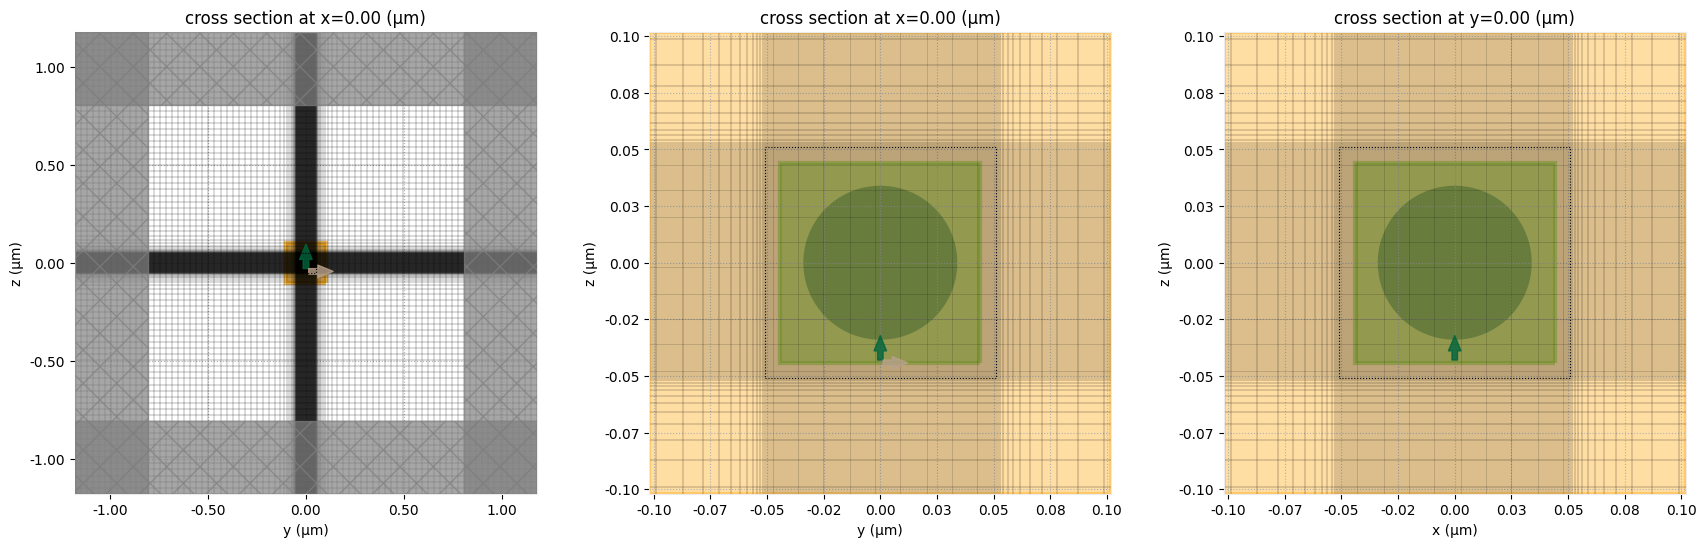

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))
zoom = radius * 3.0
sim.plot(x=0, ax=ax1)
sim.plot_grid(x=0, ax=ax1)
sim.plot(x=0, ax=ax2, hlim=[-zoom, zoom], vlim=[-zoom, zoom], monitor_alpha=0.2)
sim.plot_grid(x=0, ax=ax2, hlim=[-zoom, zoom], vlim=[-zoom, zoom])
sim.plot(y=0, ax=ax3, hlim=[-zoom, zoom], vlim=[-zoom, zoom], monitor_alpha=0.2)
sim.plot_grid(y=0, ax=ax3, hlim=[-zoom, zoom], vlim=[-zoom, zoom])
plt.show()

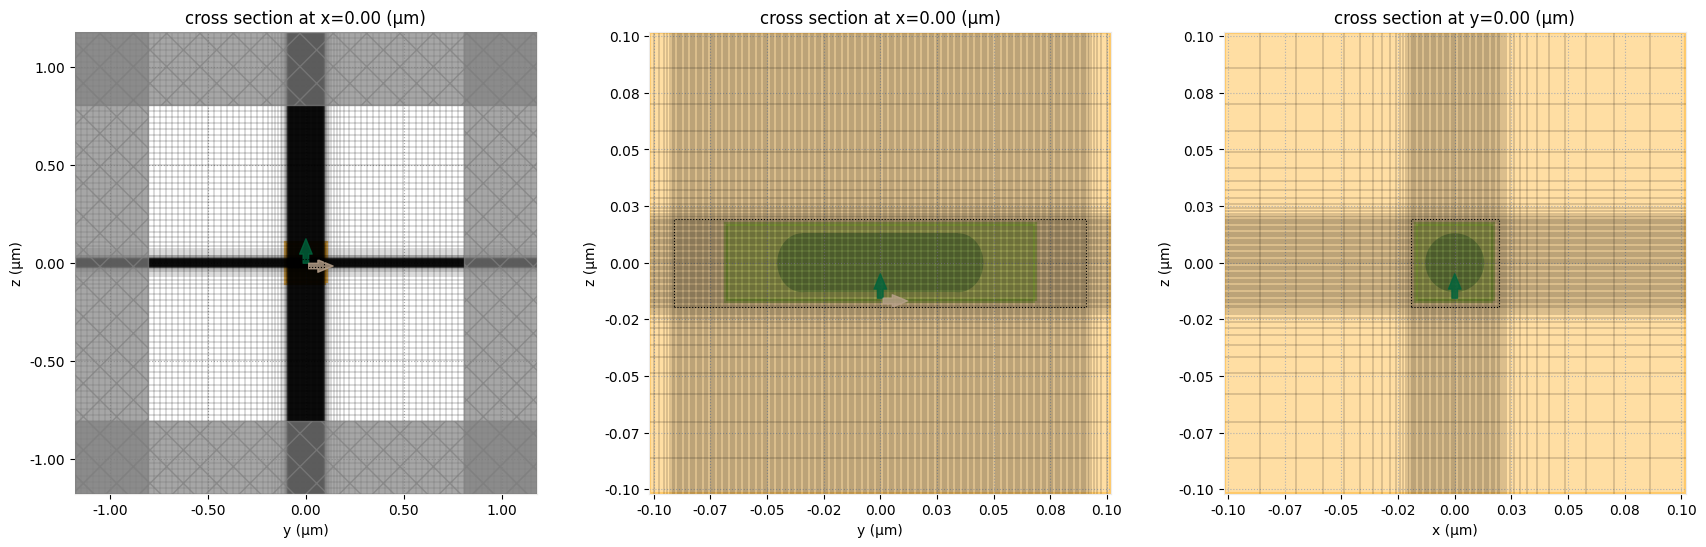

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))
zoom = radius * 3.0
sim_rod.plot(x=0, ax=ax1)
sim_rod.plot_grid(x=0, ax=ax1)
sim_rod.plot(x=0, ax=ax2, hlim=[-zoom, zoom], vlim=[-zoom, zoom], monitor_alpha=0.2)
sim_rod.plot_grid(x=0, ax=ax2, hlim=[-zoom, zoom], vlim=[-zoom, zoom])
sim_rod.plot(y=0, ax=ax3, hlim=[-zoom, zoom], vlim=[-zoom, zoom], monitor_alpha=0.2)
sim_rod.plot_grid(y=0, ax=ax3, hlim=[-zoom, zoom], vlim=[-zoom, zoom])
plt.show()

## Run the simulations

In [ ]:
# Run simulation
sim_data = web.run(
    sim,
    task_name="photothermal_heating_gold_nanoparticle",
    path="data/phototermal_heating_gold_nanoparticle.hdf5",
    verbose=True,
)

In [ ]:
# Run simulation
sim_data_rods = web.run(
    sim_rod,
    task_name="photothermal_heating_gold_nanorods",
    path="data/phototermal_heating_gold_nanorods.hdf5",
    verbose=True,
)

## Extract the results

In [ ]:
# This would guarantee that the power is scaled by 1e-3
E0 = np.sqrt(1e-3)

### Fields and power GNP (Sphere)

In [ ]:
# I can use nearest, since there is actually f0 in the linspace of frequencies
field_data = sim_data[monitor_E_field.name]
field_data_colocated = sim_data.at_boundaries(monitor_E_field.name).interp(f=f0, method="nearest")
coords = field_data_colocated.Ex.coords
coords_dict = {dim: coords.get(dim) for dim in "xyz"}

Ex = E0 * field_data.Ex.interp(f=f0, method="nearest")
Ey = E0 * field_data.Ey.interp(f=f0, method="nearest")
Ez = E0 * field_data.Ez.interp(f=f0, method="nearest")

monitor_data_perm = sim_data.monitor_data[monitor_perm.name]
perm_x = monitor_data_perm.eps_xx.interp(f=f0, method="nearest")
perm_y = monitor_data_perm.eps_yy.interp(f=f0, method="nearest")
perm_z = monitor_data_perm.eps_zz.interp(f=f0, method="nearest")

# Calculate the squared magnitude for each E-field component.
E_squared_magnitude_x = Ex * Ex.conj()
E_squared_magnitude_y = Ey * Ey.conj()
E_squared_magnitude_z = Ez * Ez.conj()
E_magnitude = np.sqrt(
    (Ex * Ex.conj()).interp(**coords_dict)
    + (Ey * Ey.conj()).interp(**coords_dict)
    + (Ez * Ez.conj()).interp(**coords_dict)
)

# Compute the power density for each E-field component using the imaginary part of permittivity.
Power_density_E_x = np.pi * f0 * td.constants.EPSILON_0 * perm_x.imag * E_squared_magnitude_x
Power_density_E_y = np.pi * f0 * td.constants.EPSILON_0 * perm_y.imag * E_squared_magnitude_y
Power_density_E_z = np.pi * f0 * td.constants.EPSILON_0 * perm_z.imag * E_squared_magnitude_z
Power_density_E = (
    Power_density_E_z.interp(**coords_dict)
    + Power_density_E_y.interp(**coords_dict)
    + Power_density_E_z.interp(**coords_dict)
)

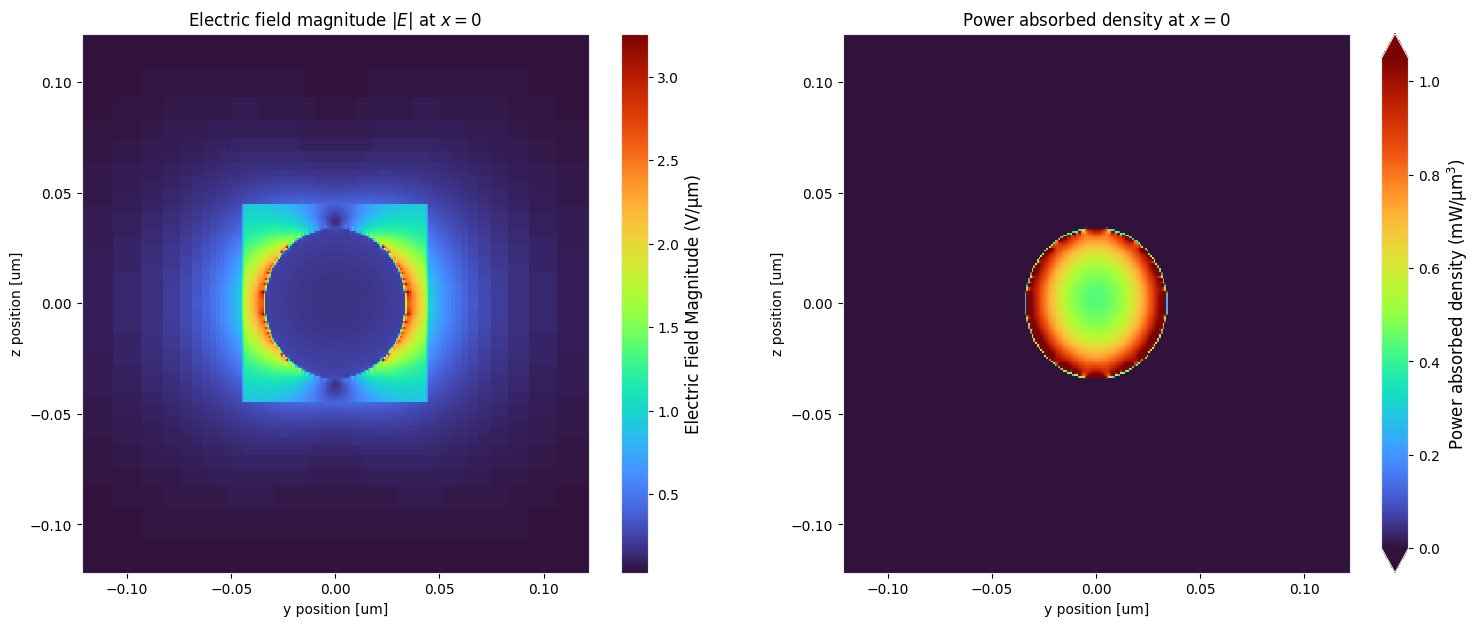

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
scaling = 1  # / Power_density_E.real.max()
fig1 = E_magnitude.sel(x=0, method="nearest").real.plot(x="y", y="z", cmap="turbo", ax=ax[0])
fig2 = (
    (1e3 * Power_density_E)
    .sel(x=0, method="nearest")
    .real.plot(x="y", y="z", cmap="turbo", ax=ax[1], robust=True)
)


colorbar_label1 = "Electric Field Magnitude (V/µm)"
fig1.colorbar.set_label(colorbar_label1, fontsize=12)
colorbar_label2 = "Power absorbed density (mW/µm$^3$)"
fig2.colorbar.set_label(colorbar_label2, fontsize=12)

_ = ax[0].set_title("Electric field magnitude $|E|$ at $x=0$")
_ = ax[1].set_title("Power absorbed density at $x=0$")

In [ ]:
abs_power_sphere = (
    Power_density_E_x.integrate(coord=["x", "y", "z"])
    + Power_density_E_y.integrate(coord=["x", "y", "z"])
    + Power_density_E_z.integrate(coord=["x", "y", "z"])
)
avg_abs_power_sphere = abs_power_sphere / sphere_geom.volume()
avg_abs_power_sphere_mw = 1e3 * avg_abs_power_sphere.real.values
print(f"Average absorbed power at 0° (angle): {avg_abs_power_sphere_mw:.3f} mW / µm^3")

Average absorbed power at 0° (angle): 0.708 mW / µm^3


### Fields and power GNR (Nanorods)

In [ ]:
# I can use nearest, since there is actually f0 in the linspace of frequencies
field_data_rods = sim_data_rods[monitor_E_field.name]
field_data_colocated_rods = sim_data_rods.at_boundaries(monitor_E_field.name).interp(
    f=f0, method="nearest"
)
coords_rods = field_data_colocated_rods.Ex.coords
coords_dict_rods = {dim: coords_rods.get(dim) for dim in "xyz"}

Ex_rods = E0 * field_data_rods.Ex.interp(f=f0, method="nearest")
Ey_rods = E0 * field_data_rods.Ey.interp(f=f0, method="nearest")
Ez_rods = E0 * field_data_rods.Ez.interp(f=f0, method="nearest")

monitor_data_perm_rods = sim_data_rods.monitor_data[monitor_perm.name]
perm_x_rods = monitor_data_perm_rods.eps_xx.interp(f=f0, method="nearest")
perm_y_rods = monitor_data_perm_rods.eps_yy.interp(f=f0, method="nearest")
perm_z_rods = monitor_data_perm_rods.eps_zz.interp(f=f0, method="nearest")

# Calculate the squared magnitude for each E-field component.
E_squared_magnitude_x_rods = Ex_rods * Ex_rods.conj()
E_squared_magnitude_y_rods = Ey_rods * Ey_rods.conj()
E_squared_magnitude_z_rods = Ez_rods * Ez_rods.conj()
E_magnitude_rods = np.sqrt(
    (Ex_rods * Ex_rods.conj()).interp(**coords_dict_rods)
    + (Ey_rods * Ey_rods.conj()).interp(**coords_dict_rods)
    + (Ez_rods * Ez_rods.conj()).interp(**coords_dict_rods)
)

# Compute the power density for each E-field component using the imaginary part of permittivity.
Power_density_E_x_rods = (
    np.pi * f0 * td.constants.EPSILON_0 * perm_x_rods.imag * E_squared_magnitude_x_rods
)
Power_density_E_y_rods = (
    np.pi * f0 * td.constants.EPSILON_0 * perm_y_rods.imag * E_squared_magnitude_y_rods
)
Power_density_E_z_rods = (
    np.pi * f0 * td.constants.EPSILON_0 * perm_z_rods.imag * E_squared_magnitude_z_rods
)
Power_density_E_rods = (
    Power_density_E_z_rods.interp(**coords_dict_rods)
    + Power_density_E_y_rods.interp(**coords_dict_rods)
    + Power_density_E_z_rods.interp(**coords_dict_rods)
)

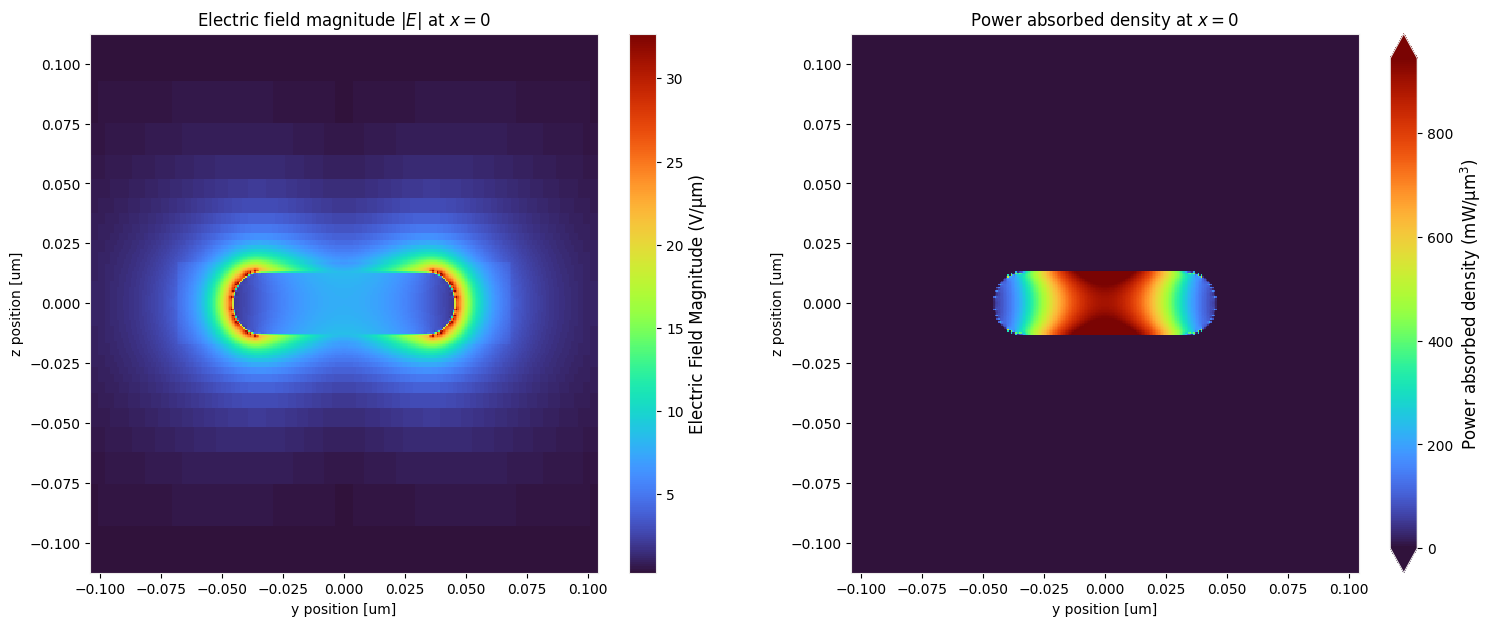

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
scaling = 1  # / Power_density_E.real.max()
fig1 = E_magnitude_rods.sel(x=0, method="nearest").real.plot(x="y", y="z", cmap="turbo", ax=ax[0])
fig2 = (
    (1e3 * Power_density_E_rods)
    .sel(x=0, method="nearest")
    .real.plot(x="y", y="z", cmap="turbo", ax=ax[1], robust=True)
)

colorbar_label1 = "Electric Field Magnitude (V/µm)"
fig1.colorbar.set_label(colorbar_label1, fontsize=12)
colorbar_label2 = "Power absorbed density (mW/µm$^3$)"
fig2.colorbar.set_label(colorbar_label2, fontsize=12)

_ = ax[0].set_title("Electric field magnitude $|E|$ at $x=0$")
_ = ax[1].set_title("Power absorbed density at $x=0$")

In [ ]:
abs_power_rod = (
    Power_density_E_x_rods.integrate(coord=["x", "y", "z"])
    + Power_density_E_y_rods.integrate(coord=["x", "y", "z"])
    + Power_density_E_z_rods.integrate(coord=["x", "y", "z"])
)
avg_abs_power_rod = abs_power_rod / rod.volume()
avg_abs_power_rod_mw = 1e3 * avg_abs_power_rod.real.values
print(f"Average absorbed power at 0° (angle): {avg_abs_power_rod_mw:.3f} mW / µm^3")

Average absorbed power at 0° (angle): 525.364 mW / µm^3


# HEAT Simulation

We will now define the physical parameters for our simulation. For the model's geometry, we will use the `td.Geometry` objects that were created at the beginning of the notebook. The thermal properties of the materials, however, will be defined in the cells below. For a steady-state thermal simulation like this one, the key material property is the thermal conductivity (k). We will also define the thermal capacity when creating our `td.Medium` objects. However, since the current solver only calculates the final steady-state temperature distribution, the capacity parameter is ignored. We've included it here for completeness and compatibility with future transient solvers.

For more details on using the heat solver, please refer to this [tutorial](https://docs.flexcompute.com/projects/tidy3d/en/latest/notebooks/HeatSolver.html) in the Tidy3D documentation.

In [ ]:
# 1. Define Materials
k_gold_SI = 310  # W/(m*K)
cp_gold_SI = 129  # J/(kg*K)

k_water_SI = 0.6  # W/(m*K)
cp_water_SI = 4184  # J/(kg*K)

gold_medium = td.Medium(
    name="gold",
    heat_spec=td.SolidSpec(
        conductivity=k_gold_SI * 1e-6,  # W/(um*K)
        capacity=cp_gold_SI,  # J/(kg*K) - it won't have effect in the version state of the solver
    ),
)

water_medium = td.Medium(
    name="water",
    heat_spec=td.SolidSpec(
        conductivity=k_water_SI * 1e-6,  # W/(um*K)
        capacity=cp_water_SI,  # J/(kg*K) - - it won't have effect in the version state of the solver
    ),
)

background_medium = td.Medium(
    heat_spec=td.FluidSpec(),
    name="background",
)

### Create scenes

Next, we create a `td.Scene` for each scenario (GNS and GNR) by building the corresponding `td.Structure` objects from the geometries and media defined above

In [ ]:
# Water sphere surrounding the nanoparticles
water_radius = 20 * radius

sphere_outer = td.Structure(
    geometry=td.Sphere(center=(0, 0, 0), radius=water_radius),
    medium=water_medium,
    name="sphere_outer",
)

In [ ]:
sphere_inner = td.Structure(
    geometry=td.Sphere(center=(0, 0, 0), radius=radius),
    medium=gold_medium,
    name="sphere_inner",
)

scene_sphere = td.Scene(
    structures=[sphere_outer, sphere_inner],
    medium=background_medium,
)

sim_heat_size = water_radius * 1.2

In [ ]:
# Nanorods
rod_inner = td.Structure(
    geometry=rod,
    medium=gold_medium,
    name="rod_inner",
)

scene_rod = td.Scene(
    structures=[sphere_outer, rod_inner],
    medium=background_medium,
)

### Boundary conditions

Here we set up the boundary conditions for our thermal simulation. Here we assume a constant temperature at the boundary of water and background.

In [ ]:
# Convert the temperature in kelvin
temperature1 = 37 + 273.15

bc = td.HeatBoundarySpec(
    condition=td.TemperatureBC(temperature=temperature1),
    placement=td.SimulationBoundary(),
)
bc2 = td.HeatBoundarySpec(
    condition=td.TemperatureBC(temperature=temperature1),
    placement=td.MediumMediumInterface(mediums=["water", "background"]),
)

### Sources

To accurately simulate the temperature increase, we must first define the source of the heat. In this case, heat is generated due to electromagnetic power absorption within the nanoparticles. We will explore two models for defining this heat source, allowing us to compare a simplified approximation with a more physically rigorous approach.

- Uniform Heat Source : Simpler and less accurate. This simpler method assumes that the heat is generated uniformly throughout the entire volume of the structure. This approach uses a single, constant value for the power density.
- Point-wise Heat Source : More sophisticated and physically accurate. The absorption of electromagnetic energy is generally not uniform in reality. It is strongest in regions where the electric field is most intense, and weaker in regions where the electric field is least intense. To capture this, we use the computed pointwise absorption power arising from the previous electromagnetic simulations to calculate the absorbed power density at every point in space.

By defining both sources, we can directly compare the results of the simplified source against the more detailed point-wise source. Simulating both scenarios will allow us to visually evaluate the impact of the heat source on the final temperature profile.

In [ ]:
## Pointwise heat source (Sphere)
source1 = np.complex128(avg_abs_power_sphere).real
source_inner = td.HeatSource(structures=["sphere_inner"], rate=source1)

## Pointwise heat source obtained from the simulation
source1_custom_data = td.SpatialDataArray(Power_density_E.real, coords=coords_dict)
source_sphere_pointwise = td.HeatSource(structures=["sphere_inner"], rate=source1_custom_data)

In [ ]:
## Pointwise heat source (Nanorods)
source_rod = np.complex128(avg_abs_power_rod).real
source_inner_rod = td.HeatSource(structures=["rod_inner"], rate=source_rod)

## Pointwise heat source obtained from the simulation
source_rods_custom_data = td.SpatialDataArray(Power_density_E_rods.real, coords=coords_dict_rods)
source_rods_pointwise = td.HeatSource(structures=["rod_inner"], rate=source_rods_custom_data)

### Create and run simulations

In [ ]:
# Temperature monitor
temp_mnt = td.TemperatureMonitor(
    center=(0, 0, 0), size=(td.inf, td.inf, td.inf), name="temperature"
)

In [ ]:
heat_sim_sphere = td.HeatChargeSimulation.from_scene(
    center=[0, 0, 0],
    size=(sim_heat_size,) * 3,
    scene=scene_sphere,
    boundary_spec=[bc, bc2],
    sources=[
        source_inner,
    ],
    grid_spec=td.UniformUnstructuredGrid(dl=radius / 5),
    monitors=[temp_mnt],
    symmetry=(1, 1, 1),
)

In [ ]:
heat_sim2_sphere = td.HeatChargeSimulation.from_scene(
    center=[0, 0, 0],
    size=(sim_heat_size,) * 3,
    scene=scene_sphere,
    boundary_spec=[bc, bc2],
    sources=[
        source_sphere_pointwise,
    ],
    grid_spec=td.UniformUnstructuredGrid(dl=radius / 5),
    monitors=[temp_mnt],
)

In [ ]:
heat_sim_rod = td.HeatChargeSimulation.from_scene(
    center=[0, 0, 0],
    size=(sim_heat_size,) * 3,
    scene=scene_rod,
    boundary_spec=[bc, bc2],
    sources=[
        source_inner_rod,
    ],
    grid_spec=td.UniformUnstructuredGrid(dl=radius / 5),
    monitors=[temp_mnt],
    symmetry=(1, 1, 1),
)

In [ ]:
heat_sim2_rod = td.HeatChargeSimulation.from_scene(
    center=[0, 0, 0],
    size=(sim_heat_size,) * 3,
    scene=scene_rod,
    boundary_spec=[bc, bc2],
    sources=[
        source_rods_pointwise,
    ],
    grid_spec=td.UniformUnstructuredGrid(dl=radius / 5),
    monitors=[temp_mnt],
    symmetry=(1, 1, 1),
)

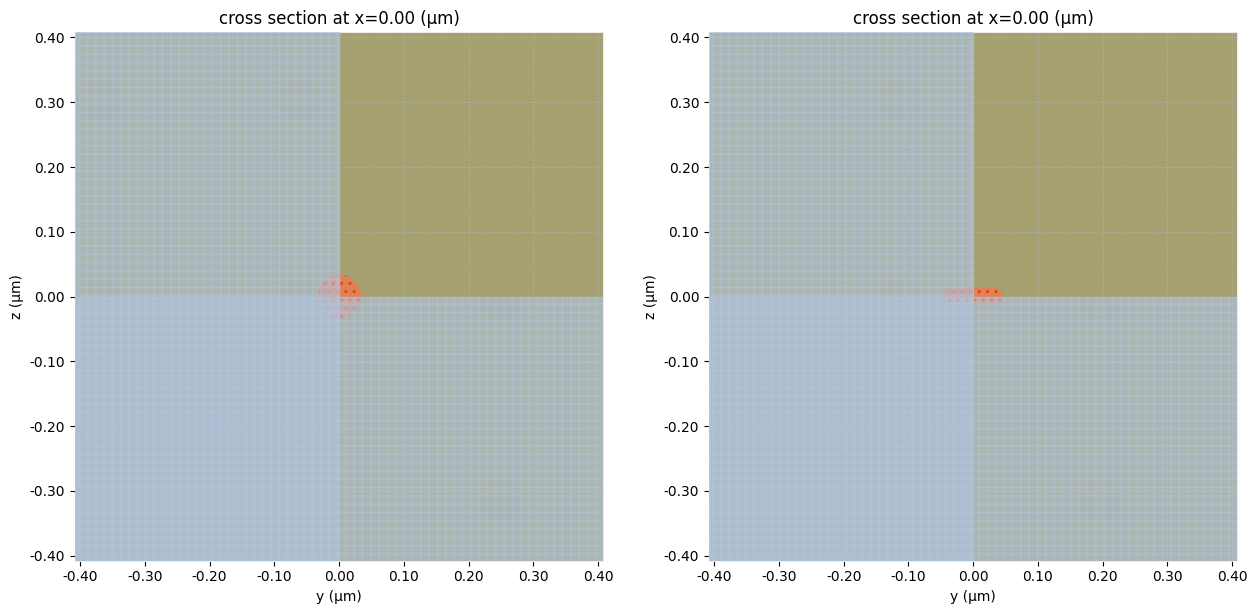

In [ ]:
# Optional: Visualize the simulation setup (good for debugging)
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
fig = heat_sim_sphere.plot(x=0, ax=ax[0])
fig = heat_sim_rod.plot(x=0, ax=ax[1])
plt.show()

In [ ]:
sim_data_heat = web.run(
    heat_sim_sphere, task_name="gold_water_heat_sphere", path="data/gold_water_heat.hdf5"
)

In [ ]:
sim_data2_heat = web.run(
    heat_sim2_sphere, task_name="gold_water_heat_sphere2", path="data/gold_water_heat2.hdf5"
)

In [ ]:
sim_data_rod = web.run(
    heat_sim_rod, task_name="gold_water_heat_rod", path="data/gold_water_heat_rod.hdf5"
)

In [ ]:
sim_data2_rod = web.run(
    heat_sim2_rod, task_name="gold_water_heat_rod2", path="data/gold_water_heat_rod2.hdf5"
)

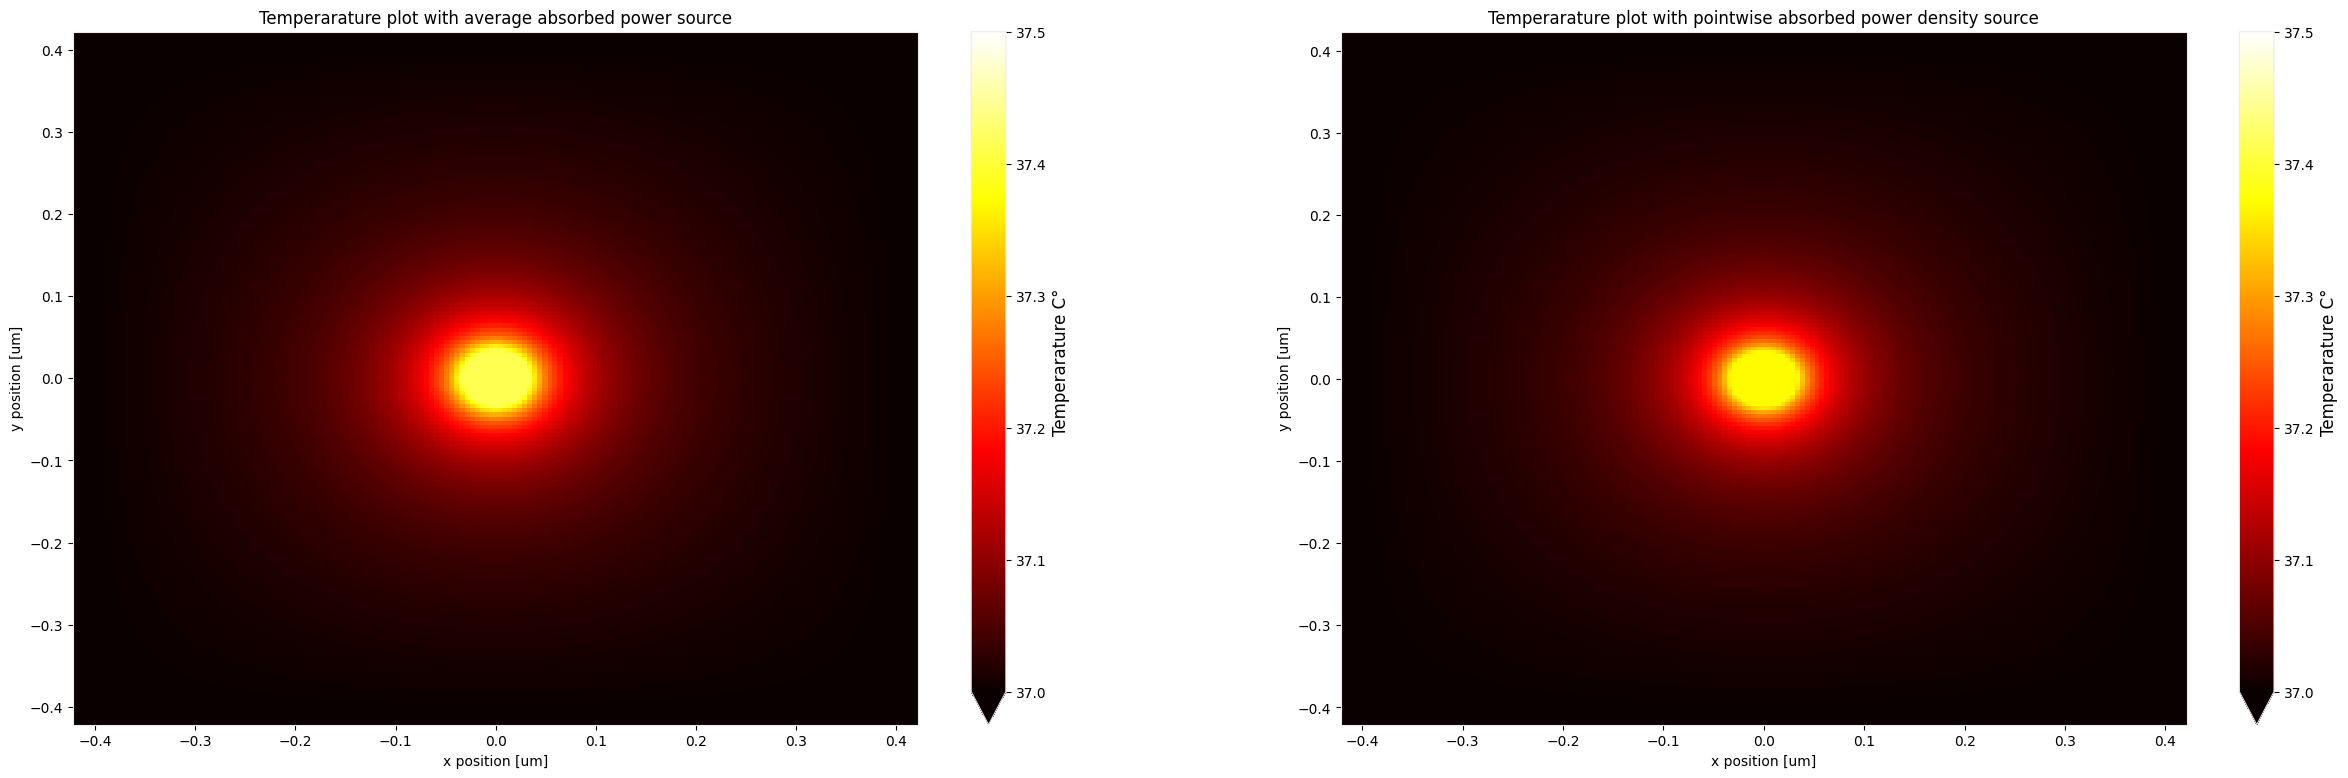

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(30, 9))
fig1 = (
    (
        (sim_data_heat.monitor_data["temperature"]).symmetry_expanded_copy.temperature
        - np.float64(273.15)
    )
    .sel(z=0, method="nearest")
    .plot(x="x", y="y", cmap="hot", ax=ax[0], vmin=37, vmax=37.5)
)
fig2 = (
    (
        (sim_data2_heat.monitor_data["temperature"]).symmetry_expanded_copy.temperature
        - np.float64(273.15)
    )
    .sel(z=0, method="nearest")
    .plot(x="x", y="y", cmap="hot", ax=ax[1], vmin=37, vmax=37.5)
)

colorbar_label = "Temperarature C°"
fig1.colorbar.set_label(colorbar_label, fontsize=12)
fig2.colorbar.set_label(colorbar_label, fontsize=12)

_ = ax[0].set_title("Temperarature plot with average absorbed power source")
_ = ax[1].set_title("Temperarature plot with pointwise absorbed power density source")

In [ ]:
max_temp_avg_source = np.float64(
    (
        (sim_data_heat.monitor_data["temperature"]).symmetry_expanded_copy.temperature
        - np.float64(273.15)
    ).max()
)
max_temp_pw_source = np.float64(
    (
        (sim_data2_heat.monitor_data["temperature"]).symmetry_expanded_copy.temperature
        - np.float64(273.15)
    ).max()
)
print("Temperature peak")
print(
    f"Average Abs. Power source: {max_temp_avg_source:.2f}° - Pointwise abs. power source: {max_temp_pw_source:.2f}°"
)

Temperature peak
Average Abs. Power source: 37.41° - Pointwise abs. power source: 37.37°


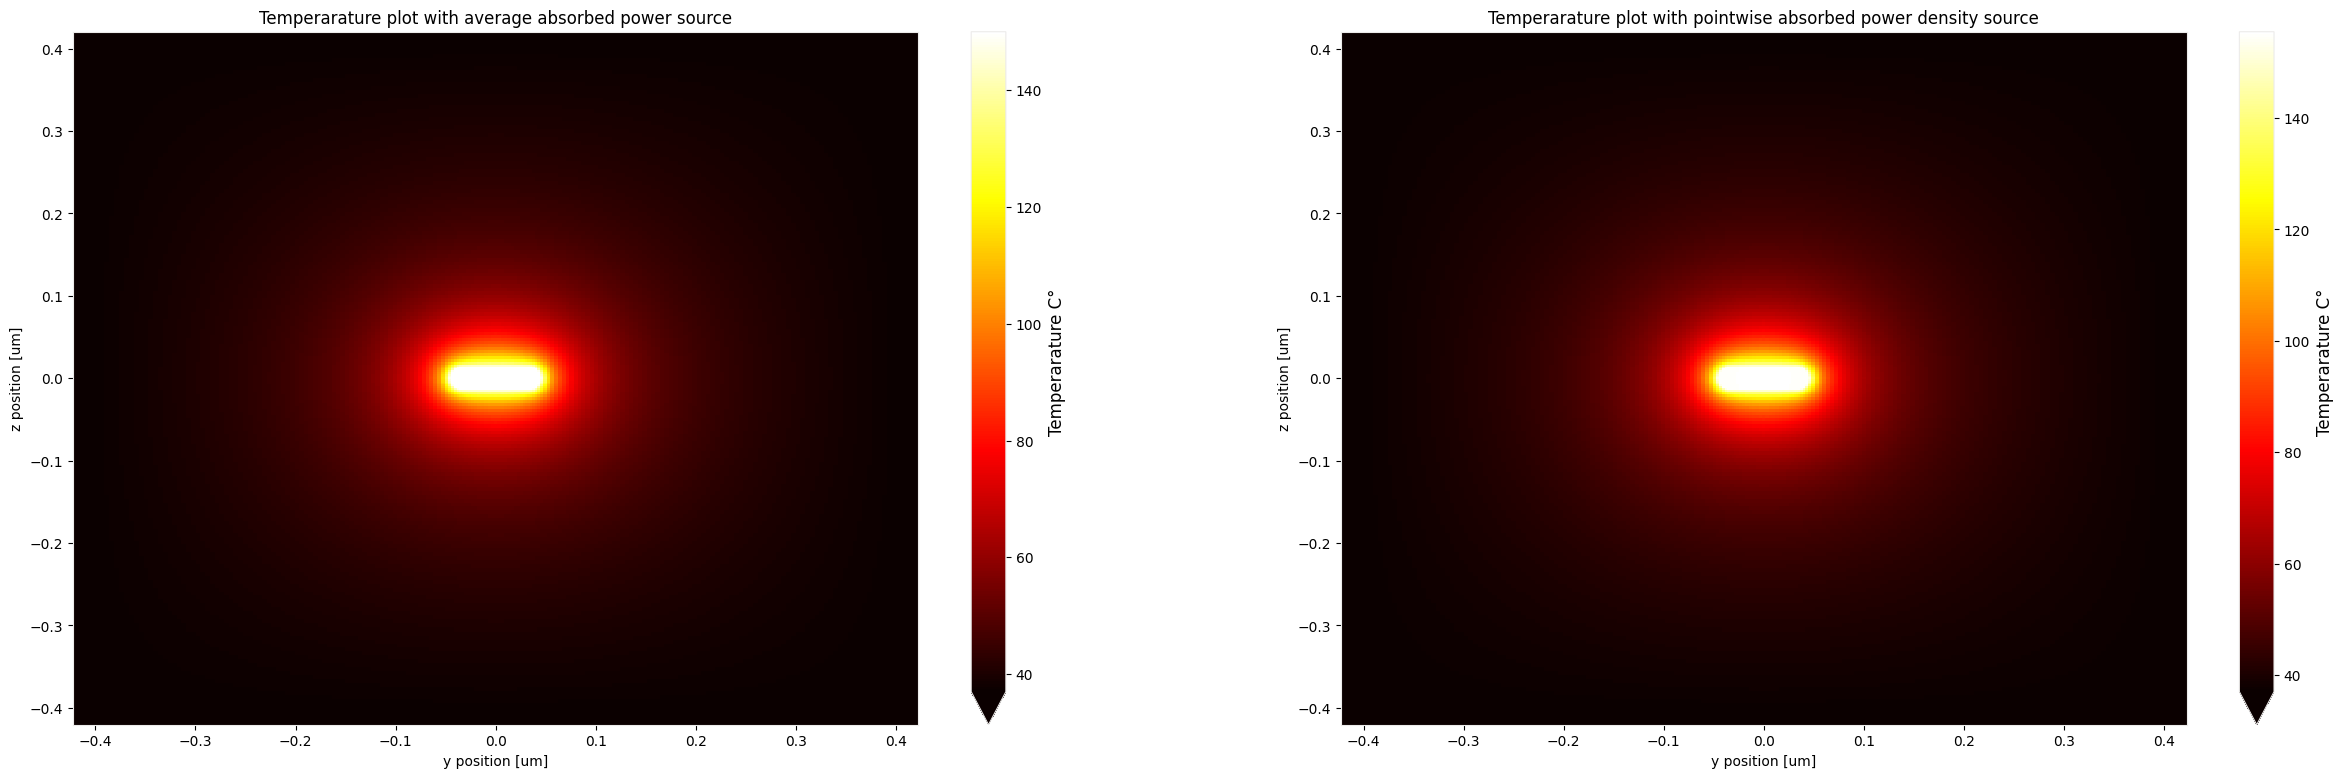

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(30, 9))
fig1 = (
    (
        (sim_data_rod.monitor_data["temperature"]).symmetry_expanded_copy.temperature
        - np.float64(273.15)
    )
    .sel(x=0, method="nearest")
    .plot(x="y", y="z", cmap="hot", ax=ax[0], vmin=37)
)
fig2 = (
    (
        (sim_data2_rod.monitor_data["temperature"]).symmetry_expanded_copy.temperature
        - np.float64(273.15)
    )
    .sel(x=0, method="nearest")
    .plot(x="y", y="z", cmap="hot", ax=ax[1], vmin=37)
)

colorbar_label = "Temperarature C°"
fig1.colorbar.set_label(colorbar_label, fontsize=12)
fig2.colorbar.set_label(colorbar_label, fontsize=12)

_ = ax[0].set_title("Temperarature plot with average absorbed power source")
_ = ax[1].set_title("Temperarature plot with pointwise absorbed power density source")

In [ ]:
max_temp_avg_source = np.float64(
    (
        (sim_data_rod.monitor_data["temperature"]).symmetry_expanded_copy.temperature
        - np.float64(273.15)
    ).max()
)
max_temp_pw_source = np.float64(
    (
        (sim_data2_rod.monitor_data["temperature"]).symmetry_expanded_copy.temperature
        - np.float64(273.15)
    ).max()
)
print("Temperature peak")
print(
    f"Average Abs. Power source: {max_temp_avg_source:.2f}° - Pointwise abs. power source: {max_temp_pw_source:.2f}°"
)

Temperature peak
Average Abs. Power source: 149.98° - Pointwise abs. power source: 155.51°


## Conclusion

We compared two models for defining a heat source in a thermal simulation: a simplified, uniform source based on the average absorbed power density, and a more rigorous, point-wise source derived from the spatially varying fields of an electromagnetic simulation.

The latest plots highlight that the choice of the heat source model impacts the resulting temperature distribution and that this impact is highly dependent on the nanostructure's geometry.

For the GNS, a highly symmetric structure, the difference between the two models is not particularly pronounced. In contrast, the results for the GNR display a slightly different temperature distribution when calculated with the point-wise source versus the average absorbed power model. In particular, the peak temperature differs by roughly 6° between the two approaches.

This suggests that a point-wise source may be preferred when accurate simulations are required.